### Pipeline to train model with XgBoost without removal of outlier
- Testing:
```
Accuracy: 0.9997325648489721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    967950
           1       1.00      1.00      1.00    265994
```
- Validation (After balancing the dataset)
```
Accuracy: 0.9276546681664792
              precision    recall  f1-score   support

           0       0.87      1.00      0.93    444500
           1       1.00      0.86      0.92    444500
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the datasets

In [ ]:
df_1 = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


In [3]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

### Drop duplicates

In [4]:
df.duplicated().sum()

np.int64(82)

In [5]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

ACC_X    0
ACC_Y    0
ACC_Z    0
ECG      0
EMG      0
EDA      0
Temp     0
Resp     0
Label    0
dtype: int64

In [5]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06
mean,8.163643e-01,-2.747610e-02,-2.947599e-01,1.532798e-03,-2.864552e-03,2.768166e+00,3.460153e+01,6.384749e-02,1.502968e+00
std,1.226097e-01,8.166216e-02,3.004658e-01,2.279383e-01,1.556006e-02,6.799757e-01,3.334515e-01,4.397762e+00,1.675910e+00
min,3.278000e-01,-3.730000e-01,-1.835000e+00,-1.499680e+00,-4.740601e-01,1.320267e+00,3.359134e+01,-4.582672e+01,0.000000e+00
25%,7.886000e-01,-6.300002e-02,-4.990000e-01,-7.374573e-02,-1.066589e-02,2.200317e+00,3.437039e+01,-2.369690e+00,0.000000e+00
50%,8.570000e-01,-3.179997e-02,-2.674000e-01,-2.838135e-02,-2.243042e-03,2.840424e+00,3.470621e+01,-2.731323e-01,1.000000e+00
75%,8.994000e-01,4.999995e-03,-7.859999e-02,8.857727e-02,5.355835e-03,3.204727e+00,3.487085e+01,2.455139e+00,3.000000e+00
max,1.966800e+00,3.346000e-01,1.086600e+00,1.499954e+00,3.534393e-01,4.241943e+00,3.523074e+01,3.297272e+01,7.000000e+00


### Data filtering

In [7]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorization

In [8]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

### handle -ve EMG

In [9]:
df["EMG"] = df["EMG"].abs()

### Handling the -Ve temp value

In [10]:
df = df[df["Temp"] > 0]

### Train test split

In [11]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

### Balance out the train dataset only

In [12]:
from sklearn.utils import resample

# majority class
low_stress = train[train["Label"] == 0]

# minority class
high_stress = train[train["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

train = pd.concat([low_downsampled, high_stress]).sample(frac=1)

train['Label'].value_counts()

Label
1    1063923
0    1063923
Name: count, dtype: int64

### Train the model

In [13]:
x_train = train.drop("Label", axis=1)
y_train = train["Label"]

y_test = test["Label"]
x_test = test.drop("Label", axis=1)

In [14]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test :", np.unique(y_test))
print("Value counts:\n", pd.Series(y_train).value_counts())

Unique labels in y_train: [0 1]
Unique labels in y_test : [0 1]
Value counts:
 Label
1    1063923
0    1063923
Name: count, dtype: int64


In [15]:
pd.DataFrame(x_train).describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp
count,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06
mean,8.134036e-01,-4.241690e-02,-3.340762e-01,1.213548e-03,1.113101e-02,4.095323e+00,3.260784e+01,5.667597e-02
std,1.252927e-01,7.898695e-02,2.623868e-01,2.285004e-01,1.380356e-02,2.812503e+00,1.789761e+00,3.487381e+00
min,3.116000e-01,-4.194000e-01,-1.050200e+00,-1.499405e+00,0.000000e+00,4.196167e-01,2.804526e+01,-2.017212e+01
25%,8.026000e-01,-1.044000e-01,-4.790000e-01,-8.839417e-02,3.250122e-03,1.669693e+00,3.132962e+01,-1.913452e+00
50%,8.634000e-01,-3.420001e-02,-3.144000e-01,-1.446533e-02,7.369995e-03,3.104019e+00,3.246747e+01,-2.700806e-01
75%,8.961999e-01,2.599955e-03,-1.606000e-01,4.829407e-02,1.414490e-02,7.085800e+00,3.441782e+01,1.899719e+00
max,1.358600e+00,5.125999e-01,1.036200e+00,1.499588e+00,1.047180e+00,1.209869e+01,3.514563e+01,1.954193e+01


In [64]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 3,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    x_train, y_train,
    eval_set              = [(x_train, y_train), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.62719	validation_1-logloss:0.62883
[10]	validation_0-logloss:0.26802	validation_1-logloss:0.27413
[20]	validation_0-logloss:0.14548	validation_1-logloss:0.14842
[30]	validation_0-logloss:0.07520	validation_1-logloss:0.07618
[40]	validation_0-logloss:0.04330	validation_1-logloss:0.04380
[50]	validation_0-logloss:0.02260	validation_1-logloss:0.02295
[60]	validation_0-logloss:0.01381	validation_1-logloss:0.01395
[70]	validation_0-logloss:0.00758	validation_1-logloss:0.00768
[80]	validation_0-logloss:0.00497	validation_1-logloss:0.00508
[90]	validation_0-logloss:0.00359	validation_1-logloss:0.00365
[99]	validation_0-logloss:0.00251	validation_1-logloss:0.00256


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Test the model with test dataset

In [65]:
X_test = test.drop("Label", axis=1)

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["Label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9997325648489721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    967950
           1       1.00      1.00      1.00    265994

    accuracy                           1.00   1233944
   macro avg       1.00      1.00      1.00   1233944
weighted avg       1.00      1.00      1.00   1233944



### Test model on other Dataset

In [40]:
validate_df =  pd.read_csv("../Dataset/S4_chest_data.csv")

In [41]:
# filtering the dataset
accept_label = [1, 2, 3, 4]
validate_df = validate_df[validate_df["Label"].isin(accept_label)]

# categorization
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

validate_df["Label"] = validate_df["Label"].apply(apply_target)

# handling -ve EMG value
validate_df["EMG"] = validate_df["EMG"].abs()


In [42]:
from sklearn.utils import resample

# majority class
low_stress = validate_df[validate_df["Label"] == 0]

# minority class
high_stress = validate_df[validate_df["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

validate_df = pd.concat([low_downsampled, high_stress]).sample(frac=1)

validate_df['Label'].value_counts()

Label
1    444500
0    444500
Name: count, dtype: int64

In [43]:
X_Validate = validate_df.drop("Label", axis=1)   
y_validate = validate_df["Label"]

In [68]:
y_pred = model.predict(X_Validate)


print("Accuracy:", accuracy_score(y_validate, y_pred))
print(classification_report(y_validate, y_pred))

Accuracy: 0.9276546681664792
              precision    recall  f1-score   support

           0       0.87      1.00      0.93    444500
           1       1.00      0.86      0.92    444500

    accuracy                           0.93    889000
   macro avg       0.94      0.93      0.93    889000
weighted avg       0.94      0.93      0.93    889000



### LIME

In [76]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("Label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [101]:
input_data = pd.DataFrame([{
    "ACC_X": 1.2,
    "ACC_Y": -0.5,
    "ACC_Z":-1.0,
    "ECG": 0.5,
    "EMG": 0.1,
    "EDA": 9.2,
    "Temp": 29.30,
    "Resp": -0.40
}])



explanation = explainer.explain_instance(
    data_row=input_data.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=8
)

explanation.as_list()

[('ACC_Z', 0.015065840332932552),
 ('Temp', 0.011316008730890486),
 ('ACC_Y', 0.009685092954585958),
 ('EMG', -0.007844531979268269),
 ('ECG', -0.0059854200659667685),
 ('EDA', -0.0016285283230422763),
 ('ACC_X', -0.0014438407413539592),
 ('Resp', -0.0008167079246088035)]

In [25]:
model.classes_

array([0, 1])

In [102]:
model.predict_proba(input_data)

array([[9.9932796e-01, 6.7203987e-04]], dtype=float32)

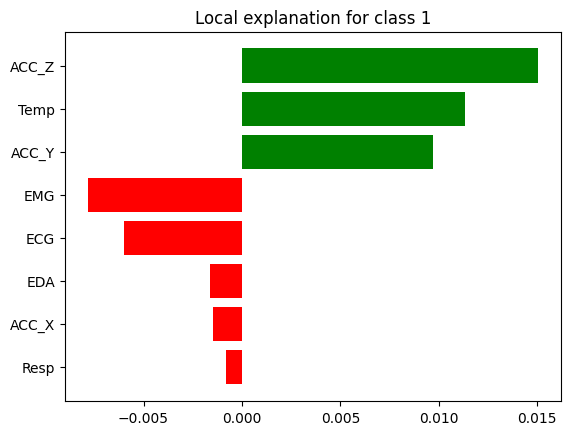

In [103]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

### SHAP

In [73]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

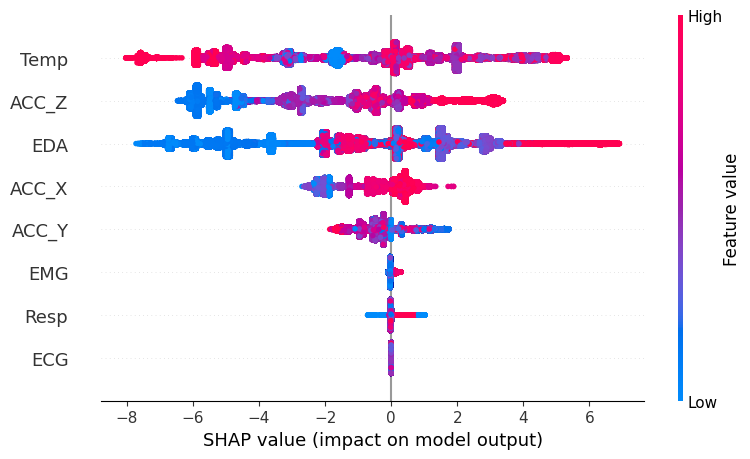

In [74]:
shap.summary_plot(shap_values, x_test)